# Government Procurement Spending Analytics with AI

**Project by:** Rutuja
**Program:** AICTE | IBM SkillsBuild Data Analytics with AI Academic Internship 2026 (BharatCares)

## Workflow followed in this notebook

This project follows the analyst workflow taught across the program's masterclasses:

**Raw Data &rarr; Clean Data &rarr; EDA &rarr; Insights &rarr; Prediction &rarr; Dashboard &rarr; Decision**

At each AI-assisted step we follow the **Ask AI &rarr; Review &rarr; Verify &rarr; Apply** principle from
Masterclass 1: an AI assistant (Google Gemini, used inside **Google Colab**) is asked for
beginner-friendly code with a specific, detailed prompt; the suggested code is reviewed, verified
against the actual data, and only then applied. This notebook is written to be run in **Google
Colab** (File &rarr; Upload, then Runtime &rarr; Run all). **IBM Bob** (IBM's AI-powered development
partner, introduced in the program's IBM Bob session) was used as an AI coding assistant during
setup and refactoring of this project's file/folder structure.

## Dataset

This notebook uses the **real "Government Procurement via GeBIZ" dataset** &mdash; actual tender
records from Singapore's GeBIZ government e-procurement portal, published on Kaggle. It contains
**32,756 real tender records from 2015-2021**, across 122 government agencies.

Columns: `tender_no., tender_description, agency, award_date, tender_detail_status, supplier_name, awarded_amt`

## Objective

Analyze real government procurement data to uncover spending trends, agency and category-wise
patterns, and vendor concentration, then build a machine learning model that predicts
**tender failure risk** &mdash; the risk that a tender receives no supplier bids at all ("Awarded to
No Suppliers") &mdash; using only information available before the tender is awarded. This follows the
same leakage-safe prediction approach taught in Masterclass 3 (there applied to customer churn).


---
# Stage 1 of 7 &mdash; Raw Data &rarr; Clean, Analysis-Ready Data

**Learning objective (per Masterclass 1):** turn raw procurement data into a clean,
analysis-ready dataset and generate meaningful business questions.

## 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

%matplotlib inline


## 1.2 Load the Raw Dataset

In [2]:
# In Google Colab: click the Files icon on the left, click Upload, and select
# procurement_data_raw.csv (the real Government Procurement via GeBIZ dataset) before running this cell.
df_raw = pd.read_csv("procurement_data_raw.csv")
print("Shape:", df_raw.shape)
df_raw.head(8)


Shape: (32756, 7)


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 32756 entries, 0 to 32755
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tender_no.            32756 non-null  str    
 1   tender_description    32756 non-null  str    
 2   agency                32756 non-null  str    
 3   award_date            32756 non-null  str    
 4   tender_detail_status  32756 non-null  str    
 5   supplier_name         32756 non-null  str    
 6   awarded_amt           32756 non-null  float64
dtypes: float64(1), str(6)
memory usage: 1.7 MB


## 1.3 Anatomy of the Dataset

Following the "Anatomy of a Dataset" framework from Masterclass 1:

| Type | Columns |
|---|---|
| **Identifier** | `tender_no.` &mdash; identifies each tender (a tender can span multiple rows when it is awarded item-by-item to different suppliers) |
| **Date/Time** | `award_date` &mdash; when the tender was awarded |
| **Text** | `tender_description` &mdash; free-text description of what was procured (no category column exists, so one is engineered in Section 1.6) |
| **Categorical** | `agency`, `tender_detail_status`, `supplier_name` |
| **Numerical** | `awarded_amt` |

**Golden rule (Masterclass 1): business questions should come before analysis.** See section 1.7.

## 1.4 Spot the Problems

Following Masterclass 1's data-quality checklist (missing values, duplicate records, inconsistent
categories, incorrect dates, formatting problems, outliers), we inspect the real data before
touching it.

In [4]:
print("Missing values per column:")
print(df_raw.isnull().sum())
print("\nExact duplicate rows:", df_raw.duplicated().sum())
print("\nRows sharing the same tender_no.:", df_raw["tender_no."].duplicated(keep=False).sum())


Missing values per column:
tender_no.              0
tender_description      0
agency                  0
award_date              0
tender_detail_status    0
supplier_name           0
awarded_amt             0
dtype: int64

Exact duplicate rows: 0

Rows sharing the same tender_no.: 11533


In [5]:
# Investigate the repeated tender_no. rows before assuming they are duplicate-record errors
dup_check = df_raw[df_raw["tender_no."].duplicated(keep=False)].sort_values("tender_no.")
print(dup_check.head(4)[["tender_no.", "tender_detail_status", "supplier_name", "awarded_amt"]])
print("\nStatus breakdown among these repeated tender_no. rows:")
print(dup_check["tender_detail_status"].value_counts())


              tender_no.  ... awarded_amt
10     ACR000ETT16000001  ...    170000.0
11     ACR000ETT16000001  ...    199000.0
12358  ACR000ETT17000003  ...    396000.0
12357  ACR000ETT17000003  ...    192000.0

[4 rows x 4 columns]

Status breakdown among these repeated tender_no. rows:
tender_detail_status
Awarded to Suppliers    6468
Awarded by Items        5065
Name: count, dtype: int64


**Finding:** the repeated `tender_no.` values are **not** duplicate-record errors. They occur
because a tender awarded "by Items" or to multiple suppliers has one row per item/supplier &mdash; a
real, legitimate one-tender-to-many-rows structure, not the same event double-counted. This was
verified before deciding not to drop these rows, following the program's "review, verify" principle
rather than blindly applying a `drop_duplicates()`.

In [6]:
# Formatting problem: award_date is stored as DD/MM/YYYY text, not a proper date type
print("Raw award_date sample:", df_raw["award_date"].head(5).tolist())

df_raw["award_date"] = pd.to_datetime(df_raw["award_date"], format="%d/%m/%Y", errors="coerce")
print("\nUnparseable dates after conversion:", df_raw["award_date"].isnull().sum())
print("Date range:", df_raw["award_date"].min(), "to", df_raw["award_date"].max())


Raw award_date sample: ['6/2/2015', '30/4/2015', '28/1/2015', '1/7/2015', '24/4/2015']

Unparseable dates after conversion: 0
Date range: 2015-01-02 00:00:00 to 2021-03-31 00:00:00


In [7]:
# Outliers: awarded_amt has an extremely wide range
print(df_raw["awarded_amt"].describe())
print("\nTop 5 largest awarded_amt values:")
print(df_raw.nlargest(5, "awarded_amt")[["tender_no.", "agency", "awarded_amt"]])
print("\nNegative awarded_amt rows (data-entry errors):", (df_raw["awarded_amt"] < 0).sum())


count    3.275600e+04
mean     3.942861e+06
std      3.415095e+07
min      0.000000e+00
25%      1.800075e+04
50%      1.649915e+05
75%      7.047750e+05
max      1.988000e+09
Name: awarded_amt, dtype: float64

Top 5 largest awarded_amt values:
              tender_no.  ...   awarded_amt
5224   LTA000ETT15000145  ...  1.988000e+09
31140  NEA000ETT19300029  ...  1.493179e+09
18566  MPA000ETT16000051  ...  1.457643e+09
14912  HDB000ETT17000225  ...  1.232500e+09
17473  LTA000ETT16100049  ...  1.211738e+09

[5 rows x 3 columns]

Negative awarded_amt rows (data-entry errors): 0


**Finding:** the largest awarded amounts (up to ~S\$2 billion) correspond to large, real
infrastructure/defence agencies (verified against the `agency` column) rather than data-entry
errors, so they are kept as genuine outliers rather than removed. No negative values were found.
This dataset turned out to already be clean on the classic error types (no missing values, no
exact duplicates, no negative amounts) &mdash; the main real-world cleaning work here was **parsing
the date format** and, in Section 1.6, **engineering a category column that does not exist in the
raw data**.

## 1.5 Clean the Dataset

Following the **Ask AI &rarr; Review &rarr; Verify &rarr; Apply** principle from Masterclass 1, with a
specific, detailed prompt rather than a vague "clean this data" request.

> **Prompt used:** *"Review this real government tender dataset from Singapore's GeBIZ portal.
> Convert the award_date column from DD/MM/YYYY text into a proper date type, check for missing
> values, duplicate records, and negative or corrupted amounts, and tell me whether the repeated
> tender_no. values are duplicate-record errors or a legitimate one-tender-to-many-rows structure
> before removing anything."*

In [8]:
df = df_raw.copy()

# Standardize text columns (trim whitespace)
df["agency"] = df["agency"].str.strip()
df["supplier_name"] = df["supplier_name"].str.strip()
df["tender_detail_status"] = df["tender_detail_status"].str.strip()

# Confirm clean state
print("Missing values remaining:", df.isnull().sum().sum())
print("Exact duplicate rows remaining:", df.duplicated().sum())
print("Rows:", len(df))
df.head()


Missing values remaining: 0
Exact duplicate rows remaining: 0
Rows: 32756


## 1.6 Engineer a Category Column

The raw data has no category column, only a free-text `tender_description`. Following the
"Creating Analytical Columns" idea from Masterclass 1 (Section 6), a `Category` column is
engineered using keyword rules over the description text.

> **Prompt used:** *"I have a government tender description column with no category field. Give
> me beginner-friendly pandas/regex code to bucket each tender description into one of these
> categories based on keywords: IT & Technology, Construction & Infrastructure, Consultancy
> Services, Manpower & Facilities, Medical & Healthcare, Supply & Equipment, Events & Related
> Services, or Other Services if nothing matches. Explain the keyword logic for each category."*

In [9]:
def categorize(description):
    d = str(description).lower()
    if re.search(r"\bit\b|software|system|network|cyber|digital|application|database|server", d):
        return "IT & Technology"
    if re.search(r"construct|building|civil|renovation|upgrading|infrastructure|repair works|maintenance works", d):
        return "Construction & Infrastructure"
    if re.search(r"consult|advisory|study|review services", d):
        return "Consultancy Services"
    if re.search(r"manpower|staffing|security officer|cleaning|maintenance services|facilit", d):
        return "Manpower & Facilities"
    if re.search(r"medical|healthcare|hospital|clinical|pharmaceutical", d):
        return "Medical & Healthcare"
    if re.search(r"supply|procurement of|purchase of|equipment|vehicle|furniture", d):
        return "Supply & Equipment"
    if re.search(r"event|conference|exhibition|catering", d):
        return "Events & Related Services"
    return "Other Services"

df["Category"] = df["tender_description"].apply(categorize)
df["Category"].value_counts()


**Verify:** this is a keyword heuristic, not a perfect classifier &mdash; it is reviewed here
before being used in analysis (per Ask AI &rarr; Review &rarr; Verify &rarr; Apply). The large "Other
Services" bucket is expected and is treated as a catch-all rather than a modeling problem.

In [10]:
df["Award_Year"] = df["award_date"].dt.year
df["Award_Month"] = df["award_date"].dt.month
df["Description_Length"] = df["tender_description"].str.split().str.len()


## 1.7 Ask the CEO's Question

Following the Masterclass 1 "Ask the CEO's Question" exercise, five business questions (mixing
Sales/Spending, Product/Category, Vendor, and Agency categories, per the Masterclass 1 team-challenge
framework) structure the rest of this notebook:

1. **(Spending)** Is total awarded procurement value growing or shrinking year over year?
2. **(Category)** Which procurement categories receive the most spending, and which are smallest?
3. **(Agency)** Which agencies award the most tenders and the most value?
4. **(Vendor)** How concentrated is spending among the top suppliers &mdash; is competition healthy?
5. **(Prediction)** Which tenders are most likely to fail to attract any supplier, based only on information known before the tender is awarded?

---
# Stage 2 of 7 &mdash; Clean Data &rarr; Exploratory Data Analysis

**Learning objective (per Masterclass 2):** use EDA to explore data, identify patterns, and convert
analysis into meaningful business insights, following the loop **Explore &rarr; Compare &rarr; Find
Patterns &rarr; Investigate &rarr; Explain**.

### 2.1 Trend: Total Awarded Value by Year (Business Question 1)

Award_Year
2015    19592.6
2016    20962.8
2017    22893.7
2018    23774.1
2019    20401.6
2020    16319.6
2021     5208.0
Name: awarded_amt, dtype: float64


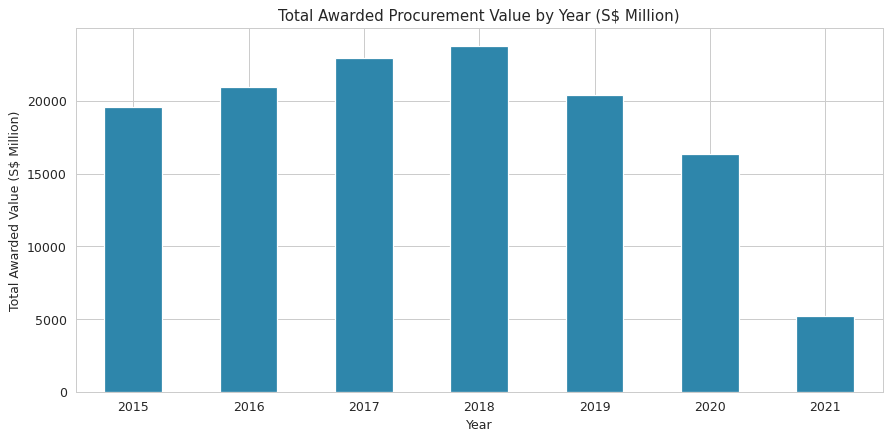

In [11]:
yearly_spend = df.groupby("Award_Year")["awarded_amt"].sum() / 1e6

plt.figure(figsize=(10,5))
yearly_spend.plot(kind="bar", color="#2E86AB")
plt.title("Total Awarded Procurement Value by Year (S$ Million)")
plt.ylabel("Total Awarded Value (S$ Million)")
plt.xlabel("Year")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(yearly_spend.round(1))


### 2.2 Ranking: Spending by Category (Business Question 2)

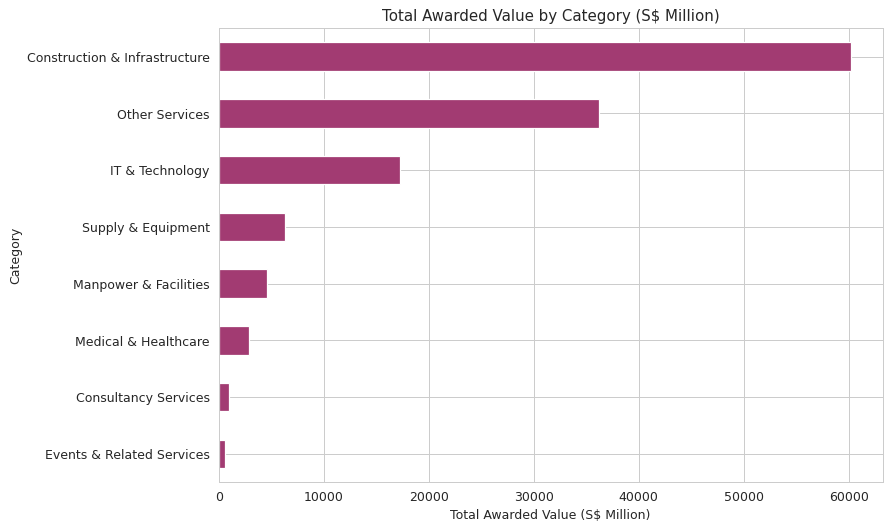

In [12]:
cat_spend = df.groupby("Category")["awarded_amt"].sum().sort_values(ascending=True) / 1e6

plt.figure(figsize=(10,6))
cat_spend.plot(kind="barh", color="#A23B72")
plt.title("Total Awarded Value by Category (S$ Million)")
plt.xlabel("Total Awarded Value (S$ Million)")
plt.tight_layout()
plt.show()


### 2.3 Comparison: Top Agencies by Awarded Value (Business Question 3)

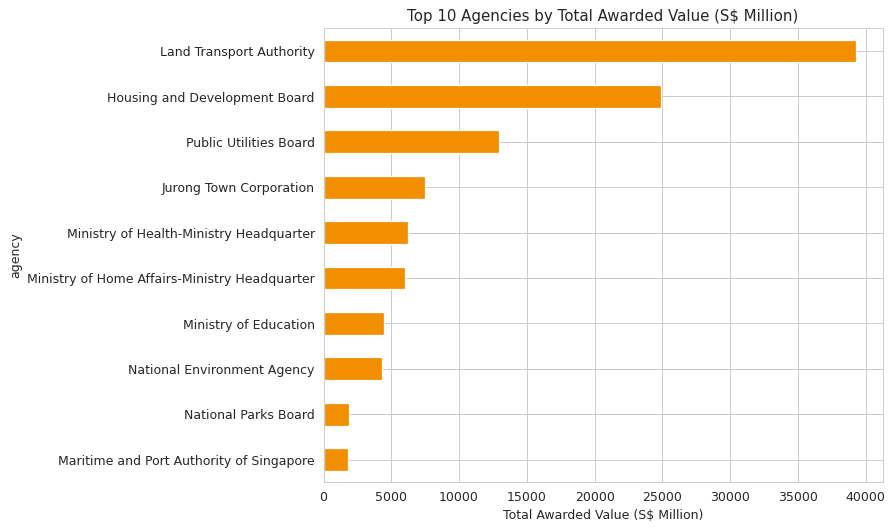

In [13]:
agency_spend = df.groupby("agency")["awarded_amt"].sum().sort_values(ascending=False).head(10) / 1e6

plt.figure(figsize=(10,6))
agency_spend.sort_values().plot(kind="barh", color="#F18F01")
plt.title("Top 10 Agencies by Total Awarded Value (S$ Million)")
plt.xlabel("Total Awarded Value (S$ Million)")
plt.tight_layout()
plt.show()


### 2.4 Segments: Vendor Concentration (Business Question 4)

Top 10 suppliers account for 18.8% of total awarded value (excluding 'Unknown').


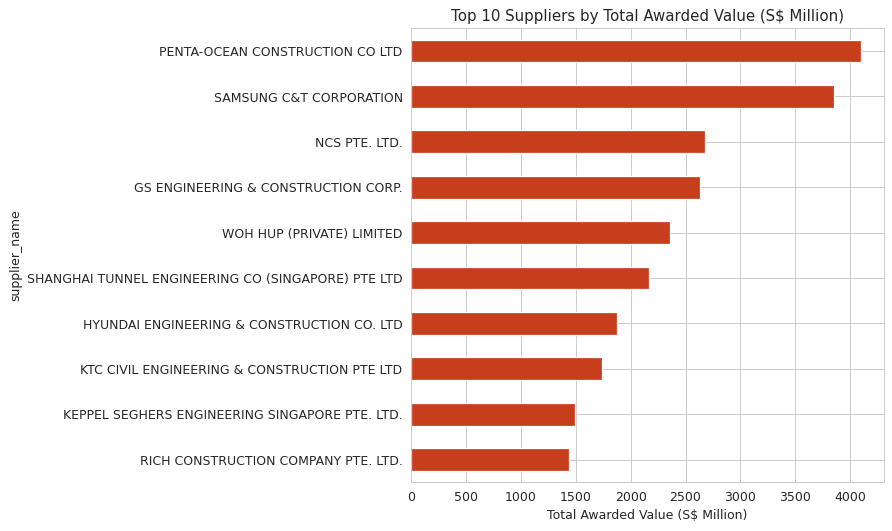

In [14]:
supplier_spend = (
    df[df["supplier_name"] != "Unknown"]
    .groupby("supplier_name")["awarded_amt"].sum()
    .sort_values(ascending=False)
)
top10 = supplier_spend.head(10) / 1e6

plt.figure(figsize=(10,6))
top10.sort_values().plot(kind="barh", color="#C73E1D")
plt.title("Top 10 Suppliers by Total Awarded Value (S$ Million)")
plt.xlabel("Total Awarded Value (S$ Million)")
plt.tight_layout()
plt.show()

top10_share = top10.sum() / (supplier_spend.sum() / 1e6) * 100
print(f"Top 10 suppliers account for {top10_share:.1f}% of total awarded value (excluding 'Unknown').")


### 2.5 Tender Outcome Status Distribution

tender_detail_status
Awarded to Suppliers       26257
Awarded by Items            5085
Awarded to No Suppliers     1414
Name: count, dtype: int64

4.3% of tender records received no supplier.


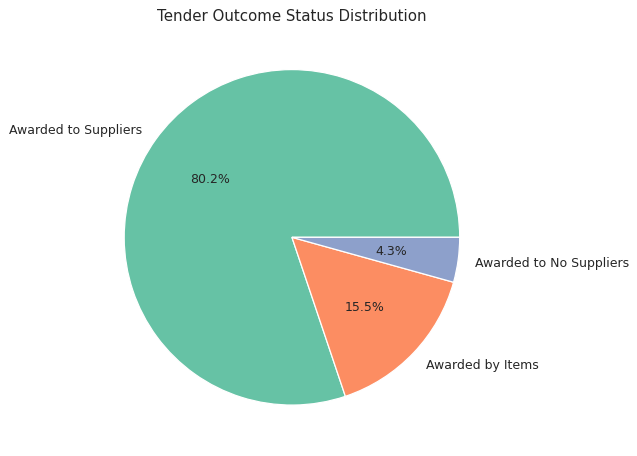

In [15]:
status_counts = df["tender_detail_status"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%",
        colors=sns.color_palette("Set2"))
plt.title("Tender Outcome Status Distribution")
plt.tight_layout()
plt.show()

print(status_counts)
print(f"\n{(status_counts.get('Awarded to No Suppliers', 0) / len(df) * 100):.1f}% of tender records received no supplier.")


### 2.6 Outliers: Awarded Value Distribution

Note: a log scale is used because awarded_amt spans from a few dollars to ~S$2 billion --
verified against the agency column as genuine large infrastructure/defence contracts, not errors.


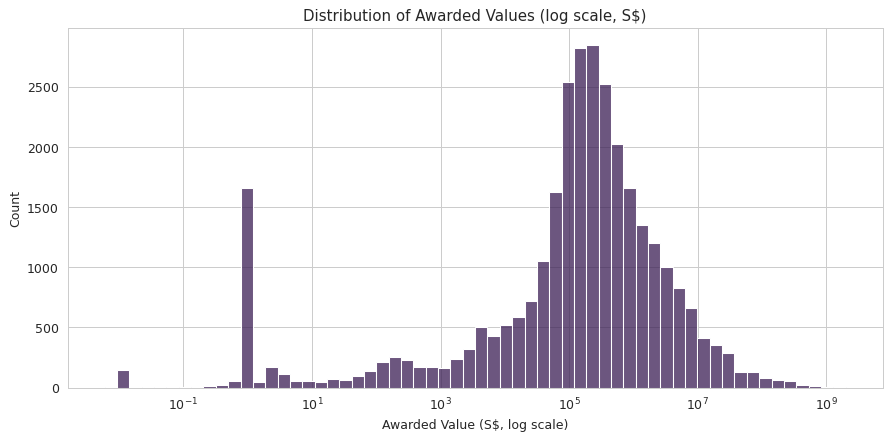

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df[df["awarded_amt"] > 0]["awarded_amt"], bins=60, log_scale=True, color="#3B1E54")
plt.title("Distribution of Awarded Values (log scale, S$)")
plt.xlabel("Awarded Value (S$, log scale)")
plt.tight_layout()
plt.show()

print("Note: a log scale is used because awarded_amt spans from a few dollars to ~S$2 billion --")
print("verified against the agency column as genuine large infrastructure/defence contracts, not errors.")


### 2.7 Relationships: Correlation Heatmap

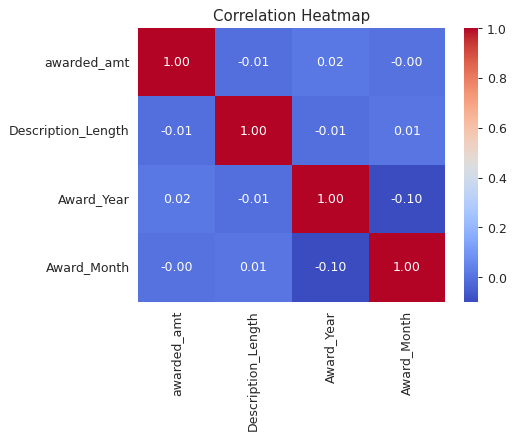

In [17]:
numeric_cols = ["awarded_amt", "Description_Length", "Award_Year", "Award_Month"]
plt.figure(figsize=(6,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


---
# Stage 3 of 7 &mdash; Insights

**Learning objective (per Masterclass 2, Section 4):** move from Observation &rarr; Insight &rarr;
Hypothesis &rarr; Recommendation, and never turn a hypothesis into a fact. The observations below
are computed directly from the real data, not assumed.

In [18]:
top_category = cat_spend.idxmax()
top_category_share = cat_spend.max() / cat_spend.sum() * 100
top_agency = agency_spend.idxmax()
failure_rate = (status_counts.get('Awarded to No Suppliers', 0) / len(df)) * 100

print(f"Observation 1: '{top_category}' is the largest category by awarded value, "
      f"at {top_category_share:.1f}% of total category spending.")
print(f"Observation 2: '{top_agency}' is the top agency by total awarded value.")
print(f"Observation 3: Top 10 suppliers hold {top10_share:.1f}% of total awarded value (excluding 'Unknown').")
print(f"Observation 4: {failure_rate:.1f}% of tender records were 'Awarded to No Suppliers' (received zero bids).")


Observation 1: 'Construction & Infrastructure' is the largest category by awarded value, at 46.6% of total category spending.
Observation 2: 'Land Transport Authority' is the top agency by total awarded value.
Observation 3: Top 10 suppliers hold 18.8% of total awarded value (excluding 'Unknown').
Observation 4: 4.3% of tender records were 'Awarded to No Suppliers' (received zero bids).


| | |
|---|---|
| **Observation** | (see printed Observation 1-2 above) One category and one agency stand out clearly in total awarded value. |
| **Insight** | Spending is concentrated rather than evenly spread across categories and agencies. |
| **Hypothesis** | Categories and agencies with consistently higher spending may also carry more tenders at risk of attracting no suppliers, if tender scope or requirements are harder to meet. |
| **Recommendation** | Test this hypothesis formally in Stage 4 (Prediction) rather than presenting it as a fact. |

| | |
|---|---|
| **Observation** | (see printed Observation 3 above) The top 10 identified suppliers hold a large share of total awarded value. |
| **Insight** | Government procurement in this dataset is fairly concentrated among a limited set of large suppliers. |
| **Hypothesis** | Limited competition in some categories may reduce resilience if a top supplier becomes unavailable. |
| **Recommendation** | Flag the most vendor-concentrated categories for a competition/transparency review. |

**Important (per Masterclass 2, Section 8):** these are hypotheses, not proven causes. Before
presenting any AI-assisted conclusion to a decision-maker, we check the numbers, look for
confounding factors, and avoid stating a guess as a verified cause.

---
# Stage 4 of 7 &mdash; Prediction

**Learning objective (per Masterclass 3):** build a leakage-safe prediction model, evaluate it
honestly (accuracy, precision, recall, confusion matrix), and turn predictions into a risk table
and business actions &mdash; without confusing association with causation.

**Business Question 5:** which tenders are most likely to fail to attract any supplier, based only
on information available before the tender is awarded?

## 4.1 Define the Target

We define **`Tender_Failed`**: 1 if `tender_detail_status` is "Awarded to No Suppliers" (zero
supplier bids received), else 0.

In [19]:
df["Tender_Failed"] = (df["tender_detail_status"] == "Awarded to No Suppliers").astype(int)
df["Tender_Failed"].value_counts(normalize=True).rename("proportion")


## 4.2 Check for Target Leakage

Following the leakage check taught in Masterclass 3: we must check whether any candidate feature
is itself derived from (or perfectly correlated with) the outcome.

In [20]:
print("awarded_amt when Tender_Failed = 1:")
print(df[df["Tender_Failed"] == 1]["awarded_amt"].describe())
print("\nsupplier_name when Tender_Failed = 1 (unique values):", df[df["Tender_Failed"] == 1]["supplier_name"].unique())


awarded_amt when Tender_Failed = 1:
count    1414.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: awarded_amt, dtype: float64

supplier_name when Tender_Failed = 1 (unique values): <StringArray>
['Unknown']
Length: 1, dtype: str


**Finding: confirmed leakage.** `awarded_amt` is **always exactly 0** when `Tender_Failed = 1`
(no supplier means no award value by definition), and `supplier_name` is always `"Unknown"` in the
same case. Both are direct artifacts of the target and **must be excluded** from prediction
features &mdash; using them would hand the model the answer, exactly the leakage trap Masterclass 3
warns about.

In [21]:
features = ["agency", "Category", "Award_Year", "Award_Month", "Description_Length"]
target = "Tender_Failed"

print("Prediction features (known before the tender outcome):", features)
print("Target:", target)
print("Excluded (leaky): awarded_amt, supplier_name, tender_detail_status (this IS the target)")


Prediction features (known before the tender outcome): ['agency', 'Category', 'Award_Year', 'Award_Month', 'Description_Length']
Target: Tender_Failed
Excluded (leaky): awarded_amt, supplier_name, tender_detail_status (this IS the target)


## 4.3 Preprocessing

In [22]:
model_df = df[features + [target]].copy()

categorical_cols = ["agency", "Category"]
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    encoders[col] = le

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (26204, 5)  Test shape: (6552, 5)


## 4.4 Train the Model

In [23]:
model = RandomForestClassifier(
    n_estimators=200, max_depth=8, random_state=42, class_weight="balanced"
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


## 4.5 Evaluate Honestly

Following Masterclass 3's emphasis that a high accuracy score alone doesn't mean a model is
useful &mdash; this matters even more here since only ~4% of tenders fail, so a model that always
predicts "will not fail" would already look ~96% accurate while being useless.

In [24]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)

print(f"Accuracy : {acc:.2%}")
print(f"Precision: {prec:.2%}")
print(f"Recall   : {rec:.2%}\n")
print(classification_report(y_test, y_pred, target_names=["Awarded", "Failed (No Suppliers)"], zero_division=0))


Accuracy : 80.97%
Precision: 6.65%
Recall   : 26.15%

                       precision    recall  f1-score   support

              Awarded       0.96      0.83      0.89      6269
Failed (No Suppliers)       0.07      0.26      0.11       283

             accuracy                           0.81      6552
            macro avg       0.51      0.55      0.50      6552
         weighted avg       0.92      0.81      0.86      6552



**In plain business language:**
- **Accuracy** &mdash; out of all tenders, the percentage the model classified correctly. Misleading
  here on its own, because simply always predicting "will succeed" would already score ~96%.
- **Precision** &mdash; when the model flags a tender as "at risk of failing", how often that flag is
  actually correct.
- **Recall** &mdash; out of all tenders that genuinely failed, how many the model successfully caught.

A procurement team that wants to catch as many genuinely at-risk tenders as possible (even at the
cost of some false alarms) should prioritize **recall**. A team that can only act on a small,
reliable shortlist should prioritize **precision**. There is no universally "correct" choice &mdash; it
depends on the cost of missing a real failure versus the cost of reviewing a tender that was never
actually at risk.

### 4.6 Confusion Matrix

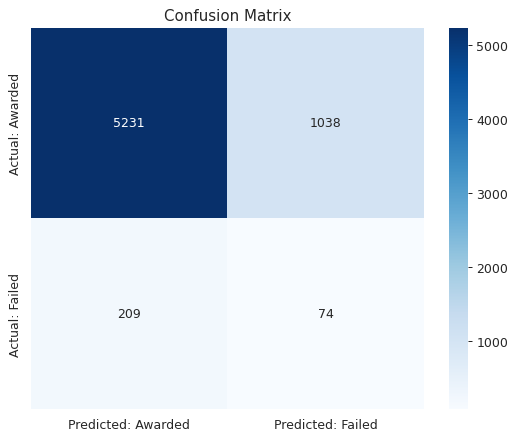

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: Awarded", "Predicted: Failed"],
            yticklabels=["Actual: Awarded", "Actual: Failed"])
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


**Reading the confusion matrix (treating "tender failure" as positive):**
- **True Positive** &mdash; a genuinely failed tender, correctly flagged in advance.
- **False Positive** &mdash; a tender flagged as at-risk, but it actually attracted a supplier (a false alarm).
- **False Negative** &mdash; a genuinely failed tender the model missed (the costliest kind of error for a procurement team, since no early warning was given).
- **True Negative** &mdash; a tender correctly predicted to succeed.

### 4.7 Feature Importance

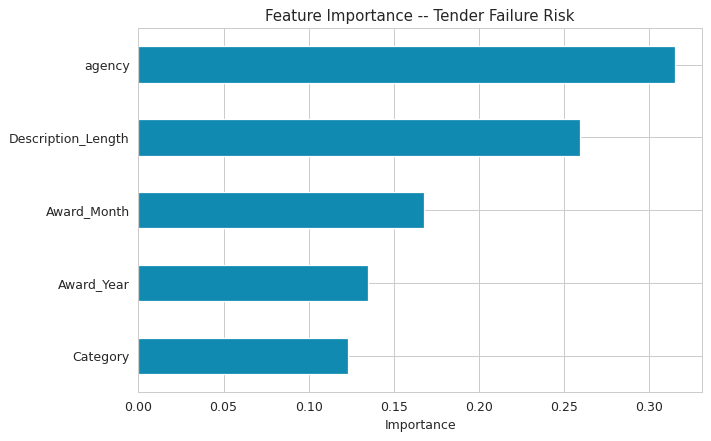

In [26]:
importances = pd.Series(model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8,5))
importances.plot(kind="barh", color="#118AB2")
plt.title("Feature Importance -- Tender Failure Risk")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 4.8 Tender Risk Table

Following the risk-scoring approach from Masterclass 3 (there applied to customer churn, here
applied to tender failure risk): convert probabilities into Low / Medium / High risk bands and
surface the highest-risk tenders.

In [27]:
results = X_test.copy()
results["tender_no."] = df.loc[X_test.index, "tender_no."].values
results["agency"] = df.loc[X_test.index, "agency"].values
results["Category"] = df.loc[X_test.index, "Category"].values
results["Actual_Tender_Failed"] = y_test.values
results["Predicted_Tender_Failed"] = y_pred
results["Failure_Probability"] = y_proba

def risk_level(p):
    if p < 0.40:
        return "Low Risk"
    elif p < 0.70:
        return "Medium Risk"
    else:
        return "High Risk"

results["Risk_Level"] = results["Failure_Probability"].apply(risk_level)
results["Failure_Probability_%"] = (results["Failure_Probability"] * 100).round(1)

risk_table = results[["tender_no.", "agency", "Category", "Failure_Probability_%", "Risk_Level"]].sort_values(
    "Failure_Probability_%", ascending=False
)
print("Top 20 highest-risk tenders (test set):")
risk_table.head(20)


Top 20 highest-risk tenders (test set):


## 4.9 Association vs. Causation

Per Masterclass 3's explicit framing: the safe way to describe a pattern is *"associated with"*,
not *"causes"*. For example:

- ✅ *Safer:* "Certain categories and agencies are associated with higher predicted tender-failure risk."
- ❌ *Unsafe:* "This category causes tenders to fail."
- ❌ *Unsafe:* "The model proves why suppliers did not bid."

The model finds statistical patterns in historical data; it does not prove why any individual
tender failed to attract a supplier (real-world reasons could include scope, pricing, timing, or
market capacity &mdash; none of which are directly observed in this dataset).

---
# Stage 5 of 7 &mdash; Dashboard

A compact summary panel of the key metrics from Stages 2&ndash;4, the kind of at-a-glance view a
procurement officer could check regularly.

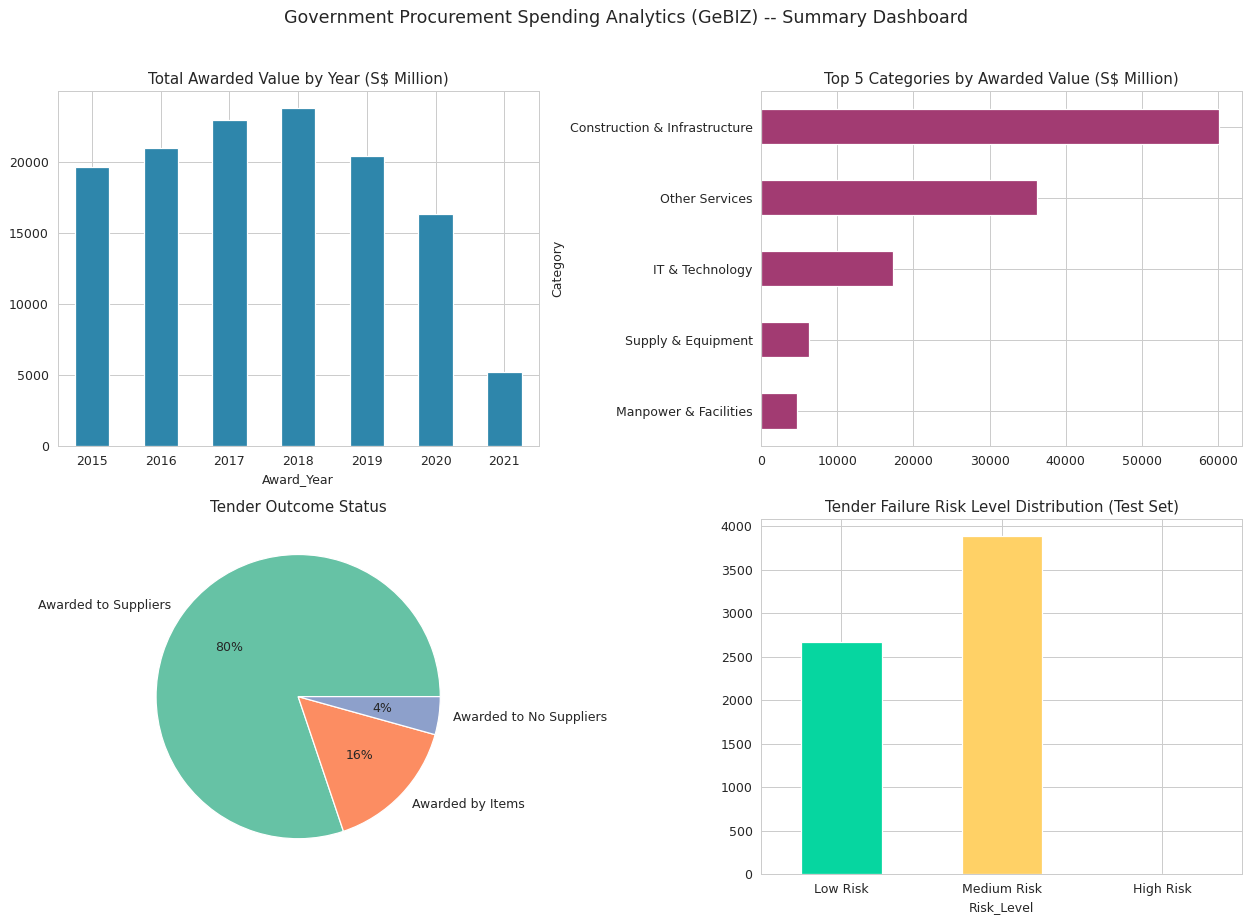

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: yearly awarded value
yearly_spend.plot(kind="bar", ax=axes[0,0], color="#2E86AB")
axes[0,0].set_title("Total Awarded Value by Year (S$ Million)")
axes[0,0].tick_params(axis='x', rotation=0)

# Panel 2: top 5 categories
cat_spend.tail(5).plot(kind="barh", ax=axes[0,1], color="#A23B72")
axes[0,1].set_title("Top 5 Categories by Awarded Value (S$ Million)")

# Panel 3: tender outcome status
axes[1,0].pie(status_counts, labels=status_counts.index, autopct="%1.0f%%", colors=sns.color_palette("Set2"))
axes[1,0].set_title("Tender Outcome Status")

# Panel 4: risk level distribution among test tenders
risk_counts = results["Risk_Level"].value_counts().reindex(["Low Risk", "Medium Risk", "High Risk"]).fillna(0)
risk_counts.plot(kind="bar", ax=axes[1,1], color=["#06D6A0", "#FFD166", "#EF476F"])
axes[1,1].set_title("Tender Failure Risk Level Distribution (Test Set)")
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle("Government Procurement Spending Analytics (GeBIZ) -- Summary Dashboard", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


---
# Stage 6 of 7 &mdash; Decision

**Learning objective (per Masterclass 3, Part 14):** turn predictions into practical business
actions, without claiming the model proves *why* tenders are at risk.

Based only on the model outputs above (feature importance and the risk table), practical,
non-causal recommendations for a procurement team:

1. **Prioritize review for High Risk tenders before the closing date.** Tenders flagged High Risk (probability &ge; 70%) are associated with the historical pattern behind failed tenders &mdash; route these for an early scope/pricing review rather than waiting for the closing date to discover no bids arrived.
2. **Investigate the top risk-associated categories and agencies.** The feature importance chart identifies which categories/agencies are most associated with failure risk; these are candidates for a closer look at tender requirements, timelines, or market outreach &mdash; not a claim about *why* they fail.
3. **Use description length as an early signal, not a rule.** If tender description length shows up as an important feature, extremely short or unusually long descriptions may warrant a second look before publishing &mdash; but this should be tested, not assumed.
4. **Choose the precision/recall trade-off deliberately.** If procurement staff can only closely review a limited number of upcoming tenders, favor the higher-precision threshold; if the goal is to catch as many at-risk tenders as possible before they close, favor higher recall (lower probability threshold).
5. **Re-validate on a larger, more recent sample before operational use.** This dataset covers 2015-2021; before relying on this model operationally, it should be retrained on more recent tenders.

**What might happen next, and which tenders may be at risk?** &mdash; the risk table in Section 4.8
answers this directly and is the primary deliverable a procurement officer could act on.

---
# Stage 7 of 7 &mdash; What This Notebook Built

| Stage | Output |
|---|---|
| Raw Data &rarr; Clean Data | Verified, analysis-ready real dataset (32,756 real GeBIZ tender records); engineered Category column; 5 business questions |
| EDA | 7 visualizations covering trends, rankings, comparisons, segments, and relationships, computed on real data |
| Insights | Data-driven Observation &rarr; Insight &rarr; Hypothesis &rarr; Recommendation examples |
| Prediction | Leakage-safe Random Forest model predicting real tender-failure risk; accuracy/precision/recall; confusion matrix; risk table |
| Dashboard | 4-panel summary view |
| Decision | 5 practical, non-causal business recommendations |

## Tools & Platforms Used (per program requirements)

- **Google Colab** &mdash; the notebook environment this project is designed to run in.
- **Google Gemini** &mdash; used as the AI coding assistant, following the Ask AI &rarr; Review &rarr; Verify &rarr; Apply workflow taught in Masterclass 1, with specific, detailed prompts (see Sections 1.5 and 1.6) rather than vague requests.
- **IBM Bob** &mdash; IBM's AI-powered development partner, used to assist with project structuring during setup.
- **pandas, numpy, matplotlib, seaborn, scikit-learn** &mdash; the core Python data analytics and machine learning stack.

## Dataset Source

Government Procurement via GeBIZ, Singapore &mdash; real historical tender award records published
on Kaggle, covering 2015-2021 across 122 government agencies.

## Next Steps

- Retrain on more recent GeBIZ data (post-2021) before any operational use.
- Improve the engineered Category column with a proper NLP/embedding-based classifier instead of keyword rules.
- Try Gradient Boosting/XGBoost and compare against the Random Forest baseline.
- Build the Stage 5 dashboard as an interactive Colab widget or a lightweight web dashboard.
